# Dfs0

A dfs0 file is also called a time series file.

Working with data from dfs0 files are conveniently done in one of two
ways:

-   [`mikeio.Dataset`](../api/Dataset.html#mikeio.Dataset) - keeps EUM
    information (convenient if you save data to new dfs0 file)
-   [`pandas.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame) -
    utilize all the powerful methods of pandas

## Read Dfs0 to Dataset

In [1]:
import mikeio

ds = mikeio.read("../data/da_diagnostic.dfs0")
ds

<mikeio.Dataset>
dims: (time:744)
time: 2017-10-27 00:00:00 - 2017-10-29 18:00:00 (744 non-equidistant records)
geometry: GeometryUndefined()
items:
  0:  State 1Sign. Wave Height <Significant wave height> (meter)
  1:  State 2Sign. Wave Height <Significant wave height> (meter)
  2:  Mean StateSign. Wave Height <Significant wave height> (meter)
  3:  MeasurementSign. Wave Height <Significant wave height> (meter)

### Selecting items

Items can be selected by name, index, or wildcard:

In [2]:
ds = mikeio.read("../data/da_diagnostic.dfs0", items=[0, 2])
ds

<mikeio.Dataset>
dims: (time:744)
time: 2017-10-27 00:00:00 - 2017-10-29 18:00:00 (744 non-equidistant records)
geometry: GeometryUndefined()
items:
  0:  State 1Sign. Wave Height <Significant wave height> (meter)
  1:  Mean StateSign. Wave Height <Significant wave height> (meter)

In [3]:
ds = mikeio.read("../data/da_diagnostic.dfs0", items="*State*")
ds

<mikeio.Dataset>
dims: (time:744)
time: 2017-10-27 00:00:00 - 2017-10-29 18:00:00 (744 non-equidistant records)
geometry: GeometryUndefined()
items:
  0:  State 1Sign. Wave Height <Significant wave height> (meter)
  1:  State 2Sign. Wave Height <Significant wave height> (meter)
  2:  Mean StateSign. Wave Height <Significant wave height> (meter)

### Subsetting in time

Use `sel` for label-based or `isel` for positional indexing:

In [4]:
ds = mikeio.read("../data/da_diagnostic.dfs0")
ds.sel(time=slice("2017-10-27 01:00", "2017-10-27 02:00"))

<mikeio.Dataset>
dims: (time:7)
time: 2017-10-27 01:00:00 - 2017-10-27 02:00:00 (7 records)
geometry: GeometryUndefined()
items:
  0:  State 1Sign. Wave Height <Significant wave height> (meter)
  1:  State 2Sign. Wave Height <Significant wave height> (meter)
  2:  Mean StateSign. Wave Height <Significant wave height> (meter)
  3:  MeasurementSign. Wave Height <Significant wave height> (meter)

In [5]:
ds.isel(time=slice(0, 5))

<mikeio.Dataset>
dims: (time:5)
time: 2017-10-27 00:00:00 - 2017-10-27 00:40:00 (5 records)
geometry: GeometryUndefined()
items:
  0:  State 1Sign. Wave Height <Significant wave height> (meter)
  1:  State 2Sign. Wave Height <Significant wave height> (meter)
  2:  Mean StateSign. Wave Height <Significant wave height> (meter)
  3:  MeasurementSign. Wave Height <Significant wave height> (meter)

### Plotting

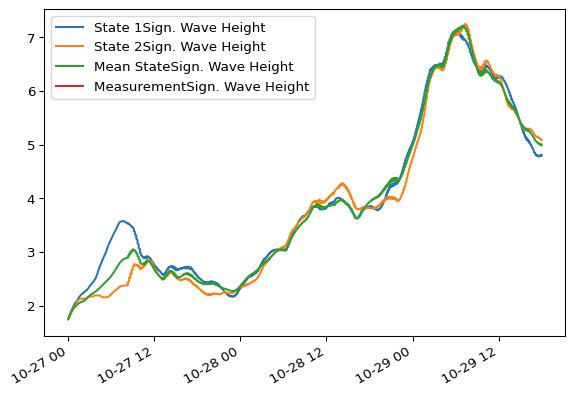

In [6]:
ds.plot();

## From Dfs0 to pandas DataFrame

In [7]:
df = ds.to_dataframe()
df.head()

## From pandas DataFrame to Dfs0

In [8]:
import pandas as pd

df = pd.read_csv(
    "../data/co2-mm-mlo.csv", parse_dates=True, index_col="Date", na_values=-99.99
)
ds = mikeio.from_pandas(df)
ds.to_dfs("mauna_loa_co2.dfs0")

### Specifying EUM types and units

By default, items created from a DataFrame have undefined EUM types. You
can specify them explicitly:

In [9]:
from mikeio import ItemInfo, EUMType, EUMUnit

df_co2 = df[["Average"]].dropna()
ds_typed = mikeio.from_pandas(
    df_co2,
    items=[ItemInfo("CO2", EUMType.Concentration_1)],
)
ds_typed

<mikeio.Dataset>
dims: (time:720)
time: 1958-03-01 00:00:00 - 2018-09-01 00:00:00 (720 non-equidistant records)
geometry: GeometryUndefined()
items:
  0:  Average <Concentration 1> (gram per meter pow 3)

## Accumulated datavalue type

Some dfs0 items use an accumulated data value type rather than the
default instantaneous type. This is common for precipitation data and
can be specified using the `data_value_type` argument of
[`mikeio.ItemInfo`](../api/ItemInfo.html#mikeio.ItemInfo). Refer to the
[MIKE
documentation](https://doc.mikepoweredbydhi.help/webhelp/2026/timeserieseditor/TSEdit/TSEdit/TS_Types_graphical_representation.htm)
for guidance on which type to use for your setup.

Rainfall amounts (e.g. mm) are often configured as `StepAccumulated`:

In [10]:
from mikeio import ItemInfo, EUMType

item = ItemInfo(
    "Rainfall",
    EUMType.Rainfall,
    data_value_type="StepAccumulated",
)
item

Rainfall <Rainfall> (millimeter) - StepAccumulated

Precipitation rates (e.g. mm/hour) are often configured as
`MeanStepBackward`:

In [11]:
item = ItemInfo(
    "Precipitation",
    EUMType.Precipitation_Rate,
    data_value_type="MeanStepBackward",
)
item

Precipitation <Precipitation Rate> (mm per day) - MeanStepBackward

Cleanup:

In [12]:
import os
os.remove("mauna_loa_co2.dfs0")

## Dfs0 example notebooks

-   [Dfs0 \| Relative time](../examples/dfs0/relative_time.qmd)